In [90]:
import pandas as pd
import datetime as dt
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import OneClassSVM
from imblearn.over_sampling import SMOTE
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn import metrics
import lime
import lime.lime_tabular

In [91]:
df = pd.read_csv("ResearhData.csv")
print(df.shape)
df.head()

(2541, 13)


,Label,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,HR_median_delta,TEMP_median_delta,ACC_vm_mean_delta,ACC_vm_sd_delta,HR_bangle_delta,HR_conf_delta,RMSSD_ECG_delta
0,NOSTRESS,-0.030326,-0.030742,0.000124,0.0,0.0,-0.810,0.3750,-1.121333,-0.036966,-0.5,-33.871843,-0.488629
1,NOSTRESS,-0.027412,-0.028501,0.003034,0.0,0.0,-1.320,0.3675,-0.771936,0.317007,-0.5,-33.871843,-0.488629
2,NOSTRESS,-0.027540,-0.028821,0.002604,0.0,0.0,-1.380,0.3625,-0.913694,0.263580,-0.5,-33.871843,-0.488629
3,NOSTRESS,-0.018734,-0.016492,0.004473,0.0,0.0,-2.285,0.4050,-0.272774,0.462842,-0.5,-33.871843,-0.488629
4,NOSTRESS,-0.012041,-0.014570,-0.005277,0.0,0.0,-2.715,0.4125,0.057561,0.002796,-0.5,-33.871843,-0.488629


In [92]:
df['Label'].unique()

array(['NOSTRESS', 'STRESS'], dtype=object)

## Data Description 

In [93]:
df.describe(include='all')

,Label,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,HR_median_delta,TEMP_median_delta,ACC_vm_mean_delta,ACC_vm_sd_delta,HR_bangle_delta,HR_conf_delta,RMSSD_ECG_delta
count,2541,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,STRESS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1312,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.133460,0.134660,0.011387,0.226682,0.025125,9.303126,-0.317973,-0.110210,0.621465,-1.519776,-31.099023,-0.441252
std,NaN,0.310719,0.314339,0.039412,0.783278,0.105890,14.661003,0.599100,0.877497,1.110321,13.332870,32.091973,4.118833
min,NaN,-1.083348,-1.065445,-0.064407,-4.000000,-0.219829,-29.775000,-2.073750,-11.392412,-7.634984,-43.500000,-99.875000,-18.977173
25%,NaN,0.038008,0.039704,-0.000006,0.000000,0.000000,0.325000,-0.748750,-0.581779,0.045387,-10.000000,-52.300000,-2.154263
50%,NaN,0.085989,0.086309,0.001395,0.000000,0.000000,7.800000,-0.265000,-0.127017,0.250669,-0.500000,-33.871843,-0.488629
75%,NaN,0.157703,0.159619,0.007714,0.000000,0.000000,15.570000,0.067500,0.366051,0.993110,8.000000,-11.863636,1.978926


## Missingness

In [94]:
missing_counts = df.isnull().sum()

missing_counts = missing_counts[missing_counts > 2541/2]

missing_counts.sort_values(ascending=False)

Series([], dtype: int64)

## Low Variability

In [95]:
from sklearn.feature_selection import VarianceThreshold

df_num = df.select_dtypes(include=['number'])

# Set your variance threshold (e.g., 0.01 is a common starting point)
my_threshold = 0.01
selector = VarianceThreshold(threshold=my_threshold)
selector.fit(df_num)

# Get boolean mask of features that pass the threshold
mask = selector.get_support()

# Get list of all column names
all_features = df_num.columns

# Features that were removed (low variance)
low_variability_features = all_features[~mask]

# Show the names of low-variability columns
print("Low variability features (variance < {:.2f}):".format(my_threshold))
print(low_variability_features.tolist())

Low variability features (variance < 0.01):
['EDA_sd_delta']


In [96]:
for col in df.select_dtypes(include='object'):
    top_freq = df[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.95:
        print(f"{col} ({top_freq:.1%})")

In [97]:
df.dtypes

Label                 object
EDA_mean_delta       float64
EDA_median_delta     float64
EDA_sd_delta         float64
SCR_count_delta      float64
SCR_amp_delta        float64
HR_median_delta      float64
TEMP_median_delta    float64
ACC_vm_mean_delta    float64
ACC_vm_sd_delta      float64
HR_bangle_delta      float64
HR_conf_delta        float64
RMSSD_ECG_delta      float64
dtype: object

## Sampling 

In [98]:
pd.crosstab(index = df['Label'], columns = "count") 

col_0,count
Label,
NOSTRESS,1229
STRESS,1312


In [99]:
train = df.groupby("Label", group_keys=False).sample(frac=0.75, random_state=1234)
test = df.loc[df.index.difference(train.index)]
train.head()


,Label,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,HR_median_delta,TEMP_median_delta,ACC_vm_mean_delta,ACC_vm_sd_delta,HR_bangle_delta,HR_conf_delta,RMSSD_ECG_delta
2220,NOSTRESS,-0.091091,-0.091315,0.000187,-2.0,-0.043149,35.41,-0.2400,-0.450977,0.439211,-1.0,-62.000000,-4.964245
850,NOSTRESS,-0.031503,-0.033947,0.009839,0.5,0.041946,57.27,-1.3125,-0.497868,2.271804,10.0,-54.428571,-1.730073
427,NOSTRESS,0.194776,0.194680,-0.000229,0.0,0.000000,-28.80,1.3750,1.841169,0.090760,2.0,-44.550000,-0.622952
1162,NOSTRESS,0.340880,0.340912,0.000109,0.5,0.041793,11.06,-0.5550,-0.509152,0.090518,-19.0,-32.500000,-1.842775
849,NOSTRESS,-0.043683,-0.041794,0.002562,0.0,0.000000,56.23,-1.3225,0.495889,0.220549,8.5,-57.918182,-4.616893


In [100]:
pd.crosstab(index = train['Label'], columns = "count")


col_0,count
Label,
NOSTRESS,922
STRESS,984


In [101]:
pd.crosstab(index = test['Label'], columns = "count")


col_0,count
Label,
NOSTRESS,307
STRESS,328


In [102]:
# filling in number dtypes with median and flagging with missing 
train_o = train.copy()
num_cols = train_o.select_dtypes(include='number').columns

for col in num_cols:
    if train_o[col].isnull().any():
        # Create missing flag column
        train_o[f'{col}_was_missing'] = train_o[col].isnull().astype(int)

        # Impute with median
        median = train_o[col].median()
        train_o[col] = train_o[col].fillna(median)
print(train_o.columns)

Index(['Label', 'EDA_mean_delta', 'EDA_median_delta', 'EDA_sd_delta',
       'SCR_count_delta', 'SCR_amp_delta', 'HR_median_delta',
       'TEMP_median_delta', 'ACC_vm_mean_delta', 'ACC_vm_sd_delta',
       'HR_bangle_delta', 'HR_conf_delta', 'RMSSD_ECG_delta'],
      dtype='object')


In [103]:
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(train_o.dtypes)


Label                 object
EDA_mean_delta       float64
EDA_median_delta     float64
EDA_sd_delta         float64
SCR_count_delta      float64
SCR_amp_delta        float64
HR_median_delta      float64
TEMP_median_delta    float64
ACC_vm_mean_delta    float64
ACC_vm_sd_delta      float64
HR_bangle_delta      float64
HR_conf_delta        float64
RMSSD_ECG_delta      float64
dtype: object


In [104]:
# creating X and Y and creating dummies for categorical data 
predictors = train_o.drop(columns=['Label'])
predictors = pd.get_dummies(predictors, drop_first=True)
predictors = predictors.astype(float)

X = predictors

y = train_o['Label']



In [105]:
# using Pearson's square to sort data and determine association, 
# Use p-value of 0.002 depending on the data siize
from sklearn.feature_selection import SelectKBest, chi2, f_classif

# Separate categorical (dummy) vs. continuous features
continuous_features = [col for col in X.columns if X[col].nunique() > 2]

X_cont = X[continuous_features]




# Fit SelectKBest for Continous Variables
selector = SelectKBest(score_func=f_classif, k='all')  # 'all' keeps all features for scoring
selector.fit(X_cont, y)

# Create a DataFrame with feature names, F-scores, and p-values
scores_cont_df = pd.DataFrame({
    'Feature': X_cont.columns,
    'F_score': selector.scores_,
    'p_value': selector.pvalues_
})

# Filter for features with p-value < 0.002
selected_cont_features = scores_cont_df[scores_cont_df['p_value'] < 0.002]['Feature']

# Create a new DataFrame with only those selected columns
X_reduced = X[selected_cont_features.tolist()]
y = train_o['Label'].map({'NOSTRESS': 0, 'STRESS': 1})

X_reduced.head()


,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,TEMP_median_delta,ACC_vm_sd_delta,HR_bangle_delta
2220,-0.091091,-0.091315,0.000187,-2.0,-0.043149,-0.2400,0.439211,-1.0
850,-0.031503,-0.033947,0.009839,0.5,0.041946,-1.3125,2.271804,10.0
427,0.194776,0.194680,-0.000229,0.0,0.000000,1.3750,0.090760,2.0
1162,0.340880,0.340912,0.000109,0.5,0.041793,-0.5550,0.090518,-19.0
849,-0.043683,-0.041794,0.002562,0.0,0.000000,-1.3225,0.220549,8.5


## Neural Network

In [106]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [107]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score


In [108]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [109]:
import optuna
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold


## Sacled 

In [110]:
from sklearn.preprocessing import StandardScaler 

unique_counts = X_reduced.nunique()

continuous_features = unique_counts[unique_counts > 2].index.tolist()
binary_features = unique_counts[unique_counts == 2].index.tolist()

final_feature_order = continuous_features + binary_features

scaler = StandardScaler()

X_cont_scaled = scaler.fit_transform(X_reduced[continuous_features])

X_binary = X_reduced[binary_features].values

X_scaled = np.hstack((X_cont_scaled, X_binary))

X_scaled_df = pd.DataFrame(X_scaled, columns=final_feature_order)

In [112]:
from sklearn.neural_network import MLPRegressor

nn_ames = MLPClassifier(max_iter = 100000, solver = 'adam',
                       alpha = 0.001,
                       activation = 'relu',
                       hidden_layer_sizes = (100,),
                       random_state = 1234)
                       
nn_ames.fit(X_scaled_df, y)

,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,100000
,shuffle,True
,random_state,1234


## GridSearch

In [113]:
from sklearn.model_selection import GridSearchCV, KFold

from sklearn.neural_network import MLPClassifier


param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'activation': ['relu', 'tanh'],
    'hidden_layer_sizes': [(80,), (90,), (100,), (110,), (120,), (50, 20), (100, 50)]
}

cv = KFold(n_splits = 10, shuffle = True, random_state = 1234)

nn = MLPClassifier(max_iter = 100000, solver = 'adam', random_state = 1234, early_stopping = True)

grid_search = GridSearchCV(estimator = nn, 
                           param_grid = param_grid, 
                           cv = cv, 
                           scoring = 'neg_mean_squared_error')

grid_search.fit(X_scaled_df, y)

,estimator,MLPClassifier...om_state=1234)
,param_grid,"{'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.001, ...], 'hidden_layer_sizes': [(80,), (90,), ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(100, ...)"


In [114]:
grid_search.best_params_

{'activation': 'relu', 'alpha': 0.1, 'hidden_layer_sizes': (100, 50)}

## Optuna

In [115]:
import optuna
from sklearn.model_selection import cross_val_score
import numpy as np

# Step 1: Define the objective using a lambda so you keep your code flat
def objective(trial):
    # Define search space (equivalent to your param_grid)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    alpha = trial.suggest_categorical('alpha', [0.0001, 0.001, 0.01, 0.1])
    hidden_layer_sizes_str = trial.suggest_categorical('hidden_layer_sizes', ['80,', '90,', '100,', '110,', '120,', '50, 20', '100, 50'])

    hidden_layer_list = [int(s) for s in hidden_layer_sizes_str.split(',') if s.strip()]
    hidden_layer_sizes_tuple = tuple(hidden_layer_list)
    
    # Create the model with suggested parameters
    nn = MLPRegressor(max_iter = 100000, solver = 'adam', early_stopping = True,
        activation = activation,
        alpha = alpha,
        hidden_layer_sizes = hidden_layer_sizes_tuple,
        random_state = 1234
    )
    
    # 10-fold CV like your original
    cv = KFold(n_splits = 10, shuffle = True, random_state = 1234)
    scores = cross_val_score(nn, X_scaled_df, y, cv = cv, scoring = 'neg_mean_squared_error')  # or 'r2'
    return np.mean(scores)

# Step 2: Run the optimization
study = optuna.create_study(direction = 'maximize')  # 'minimize' for error metrics
study.optimize(objective, n_trials = 20, show_progress_bar = True)

[I 2026-01-27 12:22:20,734] A new study created in memory with name: no-name-e6b079ed-715c-4729-9a03-5e5a8b04d05d


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-01-27 12:22:24,609] Trial 0 finished with value: -0.16927624284216655 and parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': '100, 50'}. Best is trial 0 with value: -0.16927624284216655.
[I 2026-01-27 12:22:28,512] Trial 1 finished with value: -0.188537175137658 and parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': '100,'}. Best is trial 0 with value: -0.16927624284216655.
[I 2026-01-27 12:22:30,696] Trial 2 finished with value: -0.19096925301550483 and parameters: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': '80,'}. Best is trial 0 with value: -0.16927624284216655.
[I 2026-01-27 12:22:33,508] Trial 3 finished with value: -0.19950738763569298 and parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': '120,'}. Best is trial 0 with value: -0.16927624284216655.
[I 2026-01-27 12:22:35,875] Trial 4 finished with value: -0.19155813979598543 and parameters: {'activation': 'tanh', 'alpha': 0.1, 'hidden_lay

In [116]:
# Step 3: Get the best hyperparameters
print("Best parameters:", study.best_params)

Best parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': '100, 50'}


In [117]:
print("Best score:", study.best_value)

Best score: -0.16927624284216655


In [118]:
nn_Robot = MLPClassifier(max_iter = 100000, solver = 'adam',
                       alpha = 0.0001,
                       activation = 'relu',
                       hidden_layer_sizes = (100, 50),
                       random_state = 1234)
                       
nn_Robot.fit(X_scaled_df, y)

,hidden_layer_sizes,"(100, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,100000
,shuffle,True
,random_state,1234


In [119]:
# --- Predict probabilities for the training set ---
train_o['pred_prob'] = nn_Robot.predict_proba(X_scaled_df)[:, 1]  # probability of class 1 (Stress)

# Optional: preview
train_o[['pred_prob']].head()

,pred_prob
2220,0.000262
850,0.080339
427,0.003935
1162,0.015339
849,0.914884


In [120]:
from sklearn.metrics import roc_auc_score

# --- Ensure we have predicted probabilities ---
# Already stored in train_o['pred_prob']
train_o['p_hat'] = train_o['pred_prob']  # probability of Stress = 1

# --- Compute ROC-AUC (C-statistic) ---
auc = roc_auc_score(train_o['Label'], train_o['p_hat'])
print("C-statistic (AUC):", auc)

# --- Compute Somer's D ---
somer_d = 2 * auc - 1
print("Somer's D:", somer_d)


C-statistic (AUC): 0.9752504276669663
Somer's D: 0.9505008553339327


In [121]:
from sklearn.metrics import roc_curve
import pandas as pd

# --- Ensure proper data types ---
y = train_o['Label'].map({'NOSTRESS': 0, 'STRESS': 1})


y_true = y.astype(int)

y_score = train_o['p_hat'].astype(float)

# --- Check for both classes ---
if len(set(y_true)) < 2:
    raise ValueError("y_true has only one class. Need both positive and negative samples.")

# --- Compute ROC curve ---
fpr, tpr, thresholds = roc_curve(y_true, y_score)

# --- Compute Youden's J statistic ---
youden = pd.DataFrame({
    'TPR': tpr,
    'FPR': fpr,
    'Cut-off': thresholds,
    'Youden': tpr - fpr
})

# --- Sort by Youden's J ---
youden = youden.sort_values(by='Youden', ascending=False).reset_index(drop=True)

# --- Best cutoff ---
best_threshold = youden.loc[0, 'Cut-off']
print("Best threshold (Youden's J):", best_threshold)

# Optional: show top 5 thresholds
youden.head()


Best threshold (Youden's J): 0.6037865224367667


,TPR,FPR,Cut-off,Youden
0,0.884146,0.046638,0.603787,0.837509
1,0.890244,0.053145,0.583070,0.837099
2,0.897358,0.060738,0.563033,0.836620
3,0.881098,0.045553,0.612494,0.835544
4,0.898374,0.062907,0.557262,0.835467


In [122]:
import pandas as pd

# --- Convert predicted probabilities to class labels ---
# Use 0.5 cutoff; you can also replace 0.5 with best_threshold if desired
train_o['pred'] = train_o['pred_prob'].map(lambda x: 1 if x >0.6037865224367667 else 0)

# --- Create confusion matrix ---
conf_matrix = pd.crosstab(train_o['Label'], train_o['pred'],
                          rownames=['Actual'], colnames=['Predicted'])

print("Confusion Matrix:\n", conf_matrix)

Confusion Matrix:
 Predicted    0    1
Actual             
NOSTRESS   879   43
STRESS     115  869


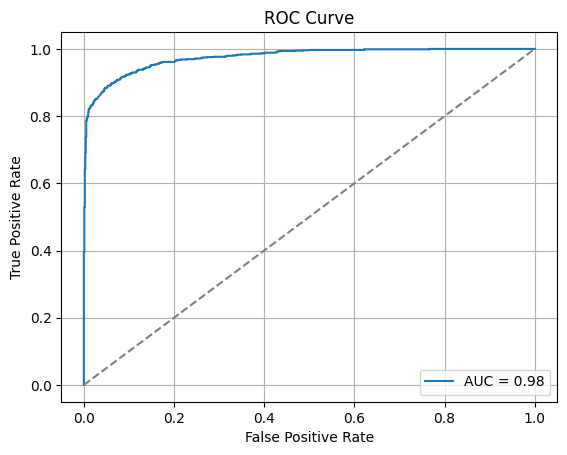

In [123]:
# Roc Curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

auc = roc_auc_score(y, train_o['pred_prob'])

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # chance line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

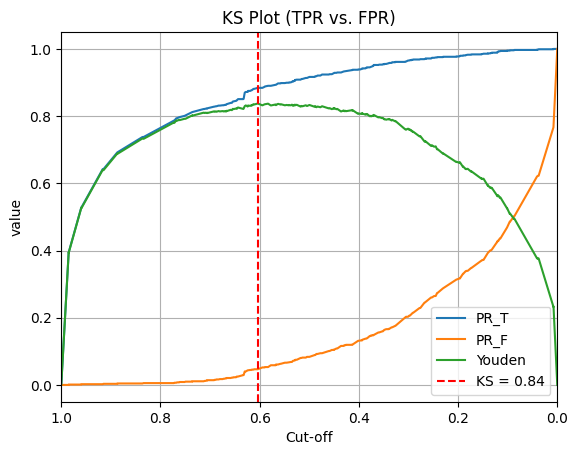

In [124]:
# KS plot 
import seaborn as sns

fpr, tpr, thresholds = roc_curve(y, train_o['pred_prob'])

# Create the Youden DataFrame
youden = pd.DataFrame({
    'Cut-off': thresholds,
    'TPR': tpr,
    'FPR': fpr,
    'Youden': tpr - fpr
})

# Sort by Cut-off and rename
youden = youden.sort_values(by='Cut-off', ascending=True)

ks_stat = youden.rename(columns={'TPR': 'PR_T', 'FPR': 'PR_F'})
ks_stat = ks_stat.melt(id_vars='Cut-off', var_name='PR', value_name='value')

ks_val = (youden['TPR'] - youden['FPR']).max()
ks_cutoff = youden.loc[(youden['TPR'] - youden['FPR']).idxmax(), 'Cut-off']

# Plot
sns.lineplot(x='Cut-off', y='value', hue='PR', data=ks_stat)
plt.xlim(1, 0)
plt.title("KS Plot (TPR vs. FPR)")
plt.grid(True)
plt.axvline(x=ks_cutoff, linestyle='--', color='red', label=f'KS = {ks_val:.2f}')
plt.legend()
plt.show()


In [125]:
# Precision, Recall, Cut-off, F1
train_o['Label'] = y
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

precision = np.array([])
recall = np.array([])
f1score = np.array([])

for y in range(100):
  train_o['pred'] = train_o['pred_prob'].map(lambda x: 1 if x > y/100 else 0)
  value_p = precision_score(train_o['Label'], train_o['pred'])
  precision = np.append(precision, value_p)
  value_r = recall_score(train_o['Label'], train_o['pred'])
  recall = np.append(recall, value_r)
  value_f = f1_score(train_o['Label'], train_o['pred'])
  f1score = np.append(f1score, value_f)

data = {'Precision': precision, 'Recall': recall, 'Cut-off': range(100), 'F1': f1score}
f1_s = pd.DataFrame(data)

f1_s.sort_values(by = ['F1'], ascending = False)

,Precision,Recall,Cut-off,F1
56,0.940362,0.897358,56,0.918357
50,0.921187,0.914634,50,0.917899
52,0.927386,0.908537,52,0.917864
53,0.930962,0.904472,53,0.917526
48,0.914228,0.920732,48,0.917468
47,0.910822,0.923780,47,0.917255
54,0.934599,0.900407,54,0.917184
51,0.922840,0.911585,51,0.917178
49,0.917599,0.916667,49,0.917133
55,0.936441,0.898374,55,0.917012


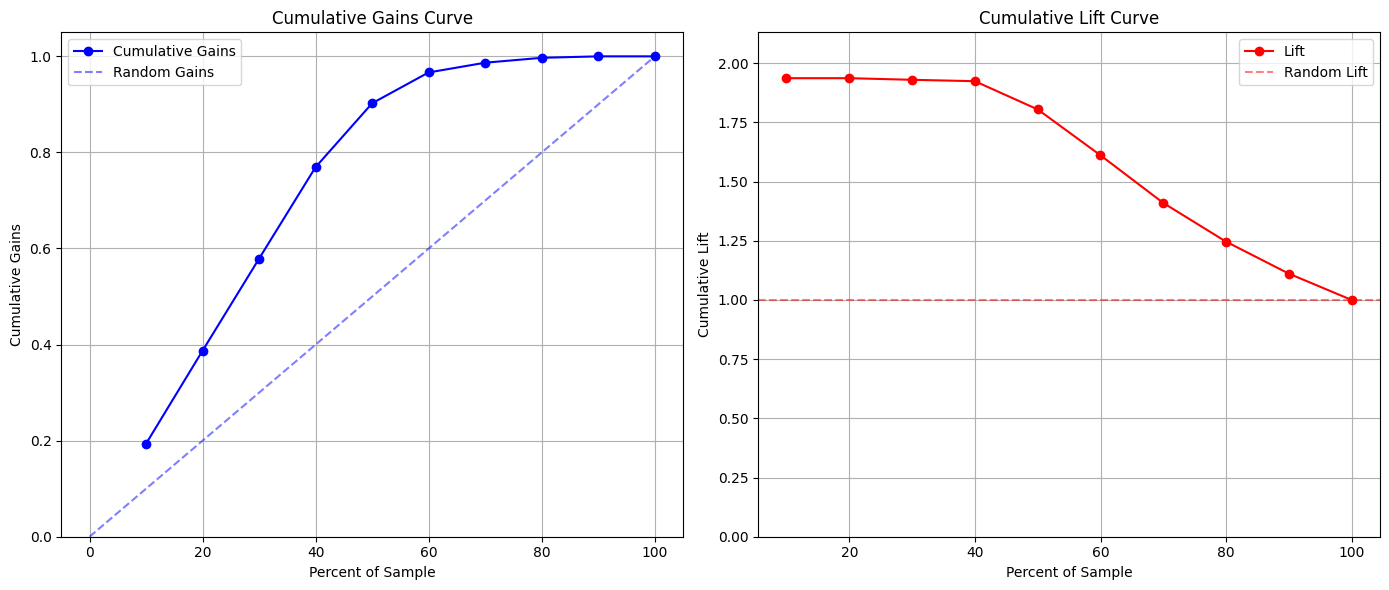

In [126]:
# Gains and lift Graph
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_lift_and_gains(y_true, y_proba, n_bins=10):
    """
    Plot Lift and Cumulative Gains curves.
    
    Parameters:
    - y_true: array-like, true binary labels (0/1)
    - y_proba: array-like, predicted probabilities for the positive class
    - n_bins: number of bins/deciles to split data
    
    Returns:
    - None (plots the curves)
    """
    df = pd.DataFrame({
        'y_true': y_true,
        'y_proba': y_proba
    })
    
    # Sort descending by predicted probability
    df = df.sort_values(by='y_proba', ascending=False).reset_index(drop=True)
    
    # Add cumulative counts
    df['cum_total'] = np.arange(1, len(df) + 1)
    df['cum_positives'] = df['y_true'].cumsum()
    
    total_positives = df['y_true'].sum()
    total_samples = len(df)
    
    # Cumulative Gains: % positives captured vs % samples
    df['cum_gains'] = df['cum_positives'] / total_positives
    
    # Lift: (cumulative gains) / (cumulative % of sample)
    df['cum_lift'] = df['cum_gains'] / (df['cum_total'] / total_samples)
    
    # Sample points for plotting (deciles)
    cutoffs = np.linspace(0, total_samples, n_bins + 1, dtype=int)
    cutoffs = cutoffs[cutoffs > 0]  # remove zero
    plot_points = df.loc[cutoffs - 1, ['cum_total', 'cum_gains', 'cum_lift']].copy()
    plot_points['percent_samples'] = plot_points['cum_total'] / total_samples * 100
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot Cumulative Gains
    axes[0].plot(plot_points['percent_samples'], plot_points['cum_gains'], marker='o', color='blue', label='Cumulative Gains')
    axes[0].plot([0, 100], [0, 1], linestyle='--', color='blue', alpha=0.5, label='Random Gains')
    axes[0].set_xlabel('Percent of Sample')
    axes[0].set_ylabel('Cumulative Gains')
    axes[0].set_title('Cumulative Gains Curve')
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(True)
    axes[0].legend()
    
    # Plot Lift
    axes[1].plot(plot_points['percent_samples'], plot_points['cum_lift'], marker='o', color='red', label='Lift')
    axes[1].axhline(1, linestyle='--', color='red', alpha=0.5, label='Random Lift')
    axes[1].set_xlabel('Percent of Sample')
    axes[1].set_ylabel('Cumulative Lift')
    axes[1].set_title('Cumulative Lift Curve')
    axes[1].set_ylim(0, plot_points['cum_lift'].max() * 1.1)
    axes[1].grid(True)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# Example:
plot_lift_and_gains(train_o['Label'], train_o['pred_prob'])


## TEST

### Transforming the test 

In [127]:
test_o= test.copy()
num_cols_test = test_o.select_dtypes(include='number').columns

for col in num_cols_test:
    if test_o[col].isnull().any():
        # Create missing flag column
        test_o[f'{col}_was_missing'] = test_o[col].isnull().astype(int)

        # Impute with median
        median = test_o[col].median()
        test_o[col] = test_o[col].fillna(median)
print(test_o.columns)

Index(['Label', 'EDA_mean_delta', 'EDA_median_delta', 'EDA_sd_delta',
       'SCR_count_delta', 'SCR_amp_delta', 'HR_median_delta',
       'TEMP_median_delta', 'ACC_vm_mean_delta', 'ACC_vm_sd_delta',
       'HR_bangle_delta', 'HR_conf_delta', 'RMSSD_ECG_delta'],
      dtype='object')


In [128]:
# Prepare test predictors
predictors_test = test_o.drop(columns=['Label'])
predictors_test = pd.get_dummies(predictors_test, drop_first=True)
predictors_test = predictors_test.astype(float)

# Align columns with training set
train_columns = X_reduced.columns  

# Add missing columns
for col in train_columns:
    if col not in predictors_test.columns:
        predictors_test[col] = 0

# Keep only training columns and order them
predictors_test = predictors_test[train_columns]

# Final X_test
X_test = predictors_test

# Correct y_test (from test_o, not train_o)
y_test = test_o['Label'].map({'NOSTRESS': 0, 'STRESS': 1})
scaler = StandardScaler()
X_test_cont_scaled = scaler.fit_transform(X_test[continuous_features])

X_test_binary = X_test[binary_features].values

X_test_scaled = np.hstack((X_test_cont_scaled, X_test_binary))

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=final_feature_order)

In [129]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, recall_score,
    precision_score, f1_score, confusion_matrix, classification_report
)
import pandas as pd

def evaluate_classification(model, X, y, model_name, threshold):
    """
    Compute classification metrics for a given model and threshold.
    
    Parameters:
    - model: fitted model with predict_proba
    - X: features
    - y: true binary labels
    - model_name: string label for output
    - threshold: probability cutoff for binary prediction
    """
    # Predicted probabilities for positive class
    y_prob = model.predict_proba(X)[:, 1]
    
    # Convert probabilities to binary predictions using threshold
    y_pred = (y_prob >= threshold).astype(int)
    
    # Compute metrics
    accuracy = accuracy_score(y, y_pred)
    auc = roc_auc_score(y, y_prob)
    recall = recall_score(y, y_pred)
    precision = precision_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    
    # Confusion matrix and classification report
    cm = confusion_matrix(y, y_pred)
    report = classification_report(y, y_pred, digits=4)
    
    # Display results
    print(f"\n====== {model_name} CLASSIFICATION PERFORMANCE ======")
    print(f"Threshold: {threshold:.6f}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    
    print("\nConfusion Matrix:")
    print(cm)
    
    print("\nClassification Report:")
    print(report)
    
    # Return metrics as dictionary for further analysis
    metrics_dict = {
        'Model': model_name,
        'Threshold': threshold,
        'Accuracy': accuracy,
        'ROC-AUC': auc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ConfusionMatrix': cm,
        'ClassificationReport': report
    }
    
    return metrics_dict


In [130]:
metrics_Random = evaluate_classification(nn_Robot, X_test_scaled, y_test, "Deep Learning", threshold=0.6037865224367667)



====== Deep Learning CLASSIFICATION PERFORMANCE ======
Threshold: 0.603787
Accuracy : 0.7480
ROC-AUC  : 0.8240
Precision: 0.7819
Recall   : 0.7104
F1 Score : 0.7444

Confusion Matrix:
[[242  65]
 [ 95 233]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7181    0.7883    0.7516       307
           1     0.7819    0.7104    0.7444       328

    accuracy                         0.7480       635
   macro avg     0.7500    0.7493    0.7480       635
weighted avg     0.7510    0.7480    0.7479       635



/home/appij25/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
